In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Model
def vector_softmax(v):
    exp_v = np.exp(v - np.max(v))
    return exp_v / np.sum(exp_v)

def matrix_softmax(X):
    X_shifted = X - np.max(X, axis=1, keepdims=True)
    exp_X = np.exp(X_shifted)
    return exp_X / np.sum(exp_X, axis=1, keepdims=True)

def prediction(data,weights,bias):
    return matrix_softmax(data@weights+bias)

def cross_entropy(label,prediction):
    return -np.mean(label*np.log(prediction))

def logistic_regression(data,labels,iterations=1000000,learning_rate=0.05):
    no_samples=np.shape(data)[0]
    no_features=np.shape(data)[1]
    no_categories=np.shape(labels)[1]
    weights=np.zeros((no_features,no_categories))
    bias=np.zeros(no_categories)
    wgrad=lambda W,b: 1/no_samples*data.T@(prediction(data,W,b)-labels) #Grad with respect to weights matrix
    bgrad=lambda W,b: np.mean(prediction(data,W,b)-labels) #Grad with respect to bias vector
    loss=[]
    #Gradient descent
    for i in range(iterations):
        weights=weights-learning_rate*wgrad(weights,bias)
        bias=bias-learning_rate*bgrad(weights,bias)
        if i%1000==0:
            cel=cross_entropy(labels,prediction(data,weights,bias))
            loss.append(cel)
    return weights,bias,loss

In [317]:
#Data preparation
training_data=pd.read_csv('phone_pricing_range_train.csv')
training_data["p0"] = (training_data["price_range"] == 0).astype(int) #Adding a column for each price range class
training_data["p1"] = (training_data["price_range"] == 1).astype(int)
training_data["p2"] = (training_data["price_range"] == 2).astype(int)
training_data["p3"] = (training_data["price_range"] == 3).astype(int)
features=np.array(training_data.drop(["p0","p1","p2","p3","price_range"],axis=1))
price_range=np.array(training_data[["p0","p1","p2","p3"]])
nonbinaryindex=np.where((features[0]!=0)&(features[0]!=1)) #Finding column indices of non binary features, I checked this manually
normalisedfeatures=np.array(training_data.drop(["p0","p1","p2","p3","price_range"],axis=1))
#Standardisation used to reduce chance of divergence or overflow during optimisation
columnmean=np.mean(normalisedfeatures[:,nonbinaryindex],axis=0)
columnstd=np.std(normalisedfeatures[:,nonbinaryindex],axis=0)
normalisedfeatures[:,nonbinaryindex]=(normalisedfeatures[:,nonbinaryindex]-columnmean)/columnstd

In [318]:
weights,bias,loss=logistic_regression(normalisedfeatures,price_range)

0.34339530906738114
0.12996350460021885
0.11068298760968893
0.1014486738844448
0.09580822102235309
0.09194308952942351
0.08910530524231594
0.08692223508847477
0.08518477256212585
0.08376553610079075
0.08258209242885745
0.08157855201212516
0.08071558925402436
0.07996468135919736
0.07930461075522591
0.07871925178755736
0.0781961205058343
0.07772539584194033
0.07729924182410217
0.07691132764342264
0.07655648106694504
0.07623043373779927
0.07592963105460529
0.07565108824663579
0.07539228002446778
0.07515105498798107
0.07492556853075281
0.07471422973016534
0.07451565892981468
0.07432865357987112
0.07415216051553465
0.07398525329876966
0.07382711357455796
0.07367701563435407
0.07353431356001036
0.07339843045776306
0.07326884939568372
0.07314510573770303
0.07302678062898081
0.07291349543544903
0.07280490697806369
0.072700703432077
0.0726006007853031
0.07250433976825885
0.07241168318425747
0.07232241357980784
0.07223633120563851
0.07215325222679563
0.07207300714692606
0.07199543941734016
0.071

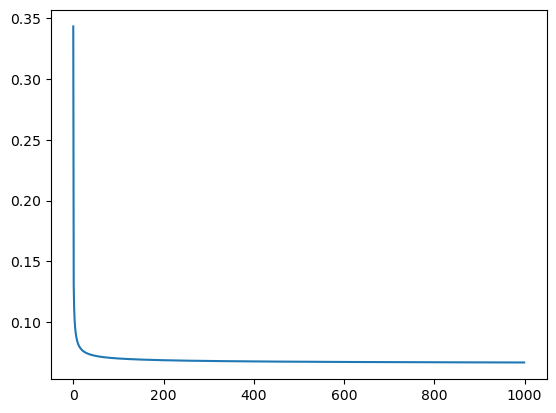

In [319]:
#Cross entropy loss during optimisation
plt.plot(range(len(loss)),loss)

In [ ]:
test1data=pd.read_csv('test1.csv')
test1data['p0']=(test1data['price_range']==0).astype(int)
test1data['p1']=(test1data['price_range']==1).astype(int)
test1data['p2']=(test1data['price_range']==2).astype(int)
test1data['p3']=(test1data['price_range']==3).astype(int)
normalised=np.array(test1data.drop(["p0","p1","p2","p3","price_range"],axis=1))
normalised[:,nonbinaryindex]=(normalised[:,nonbinaryindex]-columnmean)/columnstd
testprice=test1data[["p0","p1","p2","p3"]]
pred=prediction(normalised,weights,bias)
accuracy=(np.argmax(pred,axis=1)==np.argmax(testprice,axis=1)).mean()
print(accuracy)

0.8401360544217688


In [ ]:
test_data=pd.read_csv('phone_pricing_range_test.csv')
normalisedtest=np.array(test_data.drop(["id"],axis=1))
normalisedtest[:,nonbinaryindex]=(normalisedtest[:,nonbinaryindex]-columnmean)/columnstd
prediction=np.argmax(matrix_softmax(normalisedtest@weights+bias),axis=1)

[3 3 3 3 1 2 3 1 3 0 3 3 0 1 2 0 2 0 3 2 1 3 1 1 3 0 2 0 2 0 3 0 3 0 0 0 3
 1 2 0 1 2 0 0 0 1 0 3 1 2 1 0 3 0 3 1 3 1 1 3 3 3 0 1 0 1 2 3 1 2 0 2 2 3
 3 0 2 0 1 3 0 3 3 0 3 0 3 0 2 0 1 2 2 0 2 2 0 2 1 3 1 0 0 3 0 2 0 1 2 3 3
 3 1 3 3 3 3 3 3 0 0 2 2 1 2 0 3 2 3 2 0 3 1 1 3 1 1 0 3 2 1 3 1 2 3 3 3 3
 2 3 2 3 0 0 3 2 3 3 3 3 2 3 3 3 3 3 1 0 3 0 0 0 2 1 0 1 0 0 0 2 1 0 0 0 1
 2 2 1 0 1 0 1 1 3 1 0 3 3 2 3 0 1 3 3 3 2 2 1 1 0 1 3 1 3 2 3 0 2 0 3 2 3
 3 0 0 1 0 3 0 1 0 2 2 1 3 0 2 0 3 1 2 0 0 2 1 3 2 3 1 1 3 0 0 2 3 3 1 3 1
 1 3 2 0 2 3 3 3 1 0 1 2 3 1 0 3 2 1 3 0 0 2 0 0 3 2 3 3 2 1 3 3 2 3 1 2 0
 2 0 2 3 1 0 0 3 0 3 1 1 2 0 2 3 1 3 2 2 0 3 0 0 0 0 3 2 0 1 0 3 2 0 2 3 1
 2 2 2 3 1 3 3 2 2 2 3 3 0 3 1 3 1 3 1 2 3 0 1 0 3 1 3 2 3 0 0 0 0 2 0 0 2
 2 1 2 2 2 0 1 0 0 3 2 0 3 1 2 2 1 2 3 1 1 2 2 1 2 0 1 1 0 3 2 1 0 1 0 0 1
 1 0 0 0 3 2 3 2 3 0 3 0 3 0 1 1 1 2 0 3 3 3 3 1 3 1 3 1 3 3 1 1 2 1 1 0 0
 0 1 3 1 0 3 2 1 2 3 0 0 3 1 2 0 2 3 3 0 3 0 2 3 3 3 0 2 0 2 2 0 1 1 1 0 1
 1 1 2 3 3 2 3 1 2 2 3 3 